# members + train EDA (10만 행 샘플)
순서: 0 준비 → 1 데이터 개요·대표성 → 2 타겟 → 4 변수별 이탈률(3번 분포는 여기에 인원 수로 흡수) → 5 결측·이상값의 의미 → 6 변수 간 관계 → 7 요약

## 0. 준비: 불러오기, 병합, 한글 폰트

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_check import data_read

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

members = data_read("members_100k.csv")
trains = data_read("train_100k.csv")

# how="left": train(타겟이 있는 쪽)을 기준으로 붙임 → members에 없는 사람도 행이 남음
df = trains.merge(members, on="msno", how="left")

# 가입일: 20150312 같은 정수 → 날짜형. format="%Y%m%d"는 '연4자리 월2자리 일2자리'라는 뜻
df["registration_init_time"] = pd.to_datetime(df["registration_init_time"], format="%Y%m%d")

print("trains:", trains.shape, "/ members:", members.shape, "/ 병합:", df.shape)
print("members와 매칭되지 않은 행:", df["city"].isna().sum())

trains: (100000, 2) / members: (100000, 6) / 병합: (100000, 7)
members와 매칭되지 않은 행: 0


### 분석용 파생 컬럼
원본 컬럼은 건드리지 않고 분석용 컬럼을 따로 추가합니다.

In [2]:
# 기준 시점: 샘플 안에서 가장 늦은 가입일. 가입 기간(얼마나 오래된 고객인지)을 계산하는 기준점
BASE_DATE = df["registration_init_time"].max()
print("기준 시점:", BASE_DATE.date())

df["reg_year"] = df["registration_init_time"].dt.year
df["tenure_years"] = (BASE_DATE - df["registration_init_time"]).dt.days / 365

# pd.cut: 연속값을 구간으로 나눔
#   bins  = 구간 경계값 목록 (np.inf는 '그 이상 전부')
#   labels= 각 구간의 이름 (경계값 개수 - 1 개)
#   right=False → 왼쪽 경계 포함, 오른쪽 제외. 예) [1, 2) = 1년 이상 2년 미만
df["tenure_bin"] = pd.cut(
    df["tenure_years"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1년 미만", "1~2년", "2~3년", "3~5년", "5~10년", "10년 이상"],
    right=False,
)

# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df["gender_status"] = df["gender"].fillna("미입력")

# 나이 상태: np.select는 조건 목록을 위에서부터 검사해 처음 맞는 값을 넣음, 모두 아니면 default
df["bd_status"] = np.select(
    [df["bd"].isna(), df["bd"] == 0, df["bd"].between(10, 80)],   # between(10, 80): 10 이상 80 이하
    ["members없음", "0(미입력)", "정상"],
    default="이상치",
)

# 정상 나이만 연령대로 구간화 (나머지는 NaN)
df["age_bin"] = pd.cut(
    df["bd"].where(df["bd_status"] == "정상"),       # where: 조건이 거짓인 행은 NaN으로
    bins=[10, 20, 30, 40, 50, 60, 81],
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,
)

OVERALL = df["is_churn"].mean()   # 전체 평균 이탈률: 모든 그래프의 비교 기준선
print(f"전체 이탈률: {OVERALL:.2%}")

기준 시점: 2017-03-28
전체 이탈률: 6.42%


### 공통 함수
4~6번에서 반복해서 쓰는 '그룹별 이탈률 표 + 그래프' 함수입니다.

In [3]:
def churn_table(data, col, min_count=0):
    """col 그룹별 이탈률 표
    min_count: 인원이 이 값보다 적은 그룹은 제외 (우연히 튀는 이탈률을 거르기 위함)
    lift     : 그룹 이탈률 / 전체 이탈률. 2.0이면 평균의 두 배
    """
    t = (data.groupby(col, dropna=False, observed=True)["is_churn"]
             .agg(churn_rate="mean", count="size"))
    t["lift"] = t["churn_rate"] / OVERALL
    return t[t["count"] >= min_count]


def plot_churn(data, col, title=None, order=None, sort_by_rate=False, figsize=(10, 4)):
    """막대 = 그룹별 이탈률, 빨간 점선 = 전체 평균, 막대 위 숫자 = 그룹 인원 수
    order       : x축 순서를 직접 지정할 때
    sort_by_rate: True면 이탈률 높은 순으로 정렬
    """
    t = churn_table(data, col)
    t.index = [str(i) for i in t.index]    # NaN 그룹도 'nan'으로 표시되게 문자열화
    if order is not None:
        t = t.loc[[str(o) for o in order if str(o) in t.index]]
    elif sort_by_rate:
        t = t.sort_values("churn_rate", ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(t.index, t["churn_rate"], color="steelblue")
    ax.axhline(OVERALL, color="red", linestyle="--", label=f"전체 평균 {OVERALL:.1%}")
    for bar, n in zip(bars, t["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"n={n:,}", ha="center", va="bottom", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_xlabel(col)
    ax.set_ylabel("이탈률")
    ax.set_title(title or f"{col}별 이탈률")
    ax.legend()
    plt.xticks(rotation=45 if len(t) > 8 else 0)
    plt.tight_layout()
    plt.show()
    return t

## 1. 데이터 개요와 샘플 대표성

In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "결측 수": df.isna().sum(),
    "결측 비율": (df.isna().mean() * 100).round(2),
    "고유값 수": df.nunique(),
})
print("완전 중복 행:", df.duplicated().sum(), "/ msno 중복:", df["msno"].duplicated().sum())
overview

완전 중복 행: 0 / msno 중복: 0


,dtype,결측 수,결측 비율,고유값 수
msno,object,0,0.00,100000
is_churn,int64,0,0.00,2
city,int64,0,0.00,21
bd,int64,0,0.00,117
gender,object,52791,52.79,2
registered_via,int64,0,0.00,5
registration_init_time,datetime64[ns],0,0.00,4667
reg_year,int32,0,0.00,14
tenure_years,float64,0,0.00,4667
tenure_bin,category,0,0.00,6


In [6]:
# bd 이상값 현황: 0, 음수, 80 초과가 각각 얼마나 되는지
print(df["bd"].describe())
df["bd_status"].value_counts()

count    100000.000000
mean         14.142400
std          25.140077
min       -3152.000000
25%           0.000000
50%           0.000000
75%          28.000000
max        2016.000000
Name: bd, dtype: float64


bd_status
0(미입력)    52978
정상        46922
이상치         100
Name: count, dtype: int64

In [8]:
# 샘플 대표성: 원본 전체 병합 데이터의 이탈률(노트북에서 확인했던 값)과 비교
ORIGINAL_CHURN_RATE = 0.0899   # 원본 기준 is_churn=1 비율. 원본을 다시 계산했다면 그 값으로 교체

print(f"샘플 이탈률: {OVERALL:.2%}  /  원본 이탈률: {ORIGINAL_CHURN_RATE:.2%}")
print(f"차이: {(OVERALL - ORIGINAL_CHURN_RATE) * 100:+.2f}%p")
# 차이가 크면 → 10만 행을 어떤 방식으로 뽑았는지 팀과 확인 (무작위인지, 특정 조건으로 걸렀는지)

샘플 이탈률: 6.42%  /  원본 이탈률: 8.99%
차이: -2.57%p


## 2. 타겟 분포

,count,ratio
is_churn,,
0,93578,0.9358
1,6422,0.0642


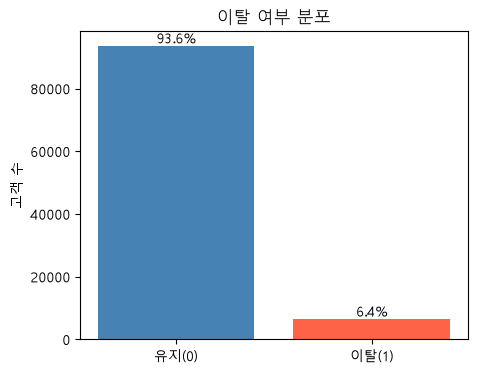

In [9]:
target = df["is_churn"].value_counts().sort_index()
ratio = df["is_churn"].value_counts(normalize=True).sort_index()   # normalize=True → 개수 대신 비율
display(pd.DataFrame({"count": target, "ratio": ratio.round(4)}))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["유지(0)", "이탈(1)"], target.values, color=["steelblue", "tomato"])
for bar, r in zip(bars, ratio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{r:.1%}", ha="center", va="bottom")
ax.set_title("이탈 여부 분포")
ax.set_ylabel("고객 수")
plt.show()
# 결론 메모: 클래스 불균형 → 정확도(accuracy)만으로 모델을 평가하면 안 됨

## 4. 변수별 이탈률 비교
막대 위 n은 그룹 인원 수입니다. 인원이 적은 그룹의 이탈률은 해석에 주의하세요.

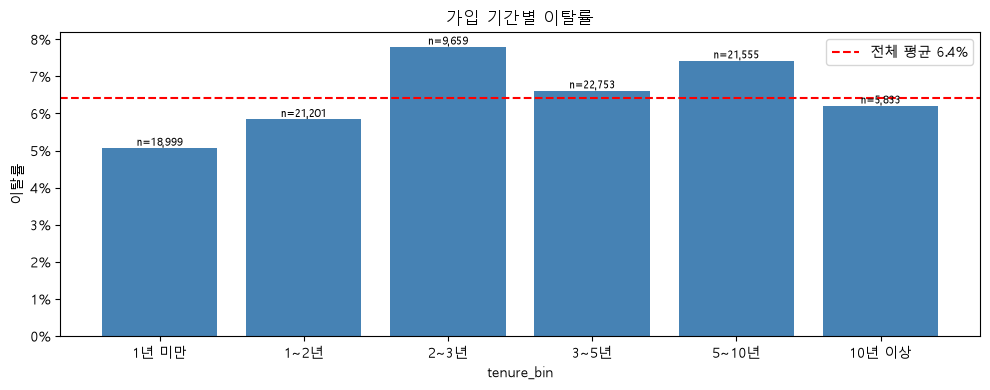

,churn_rate,count,lift
1년 미만,0.050687,18999,0.789269
1~2년,0.058441,21201,0.910007
2~3년,0.077958,9659,1.213927
3~5년,0.066145,22753,1.029977
5~10년,0.074229,21555,1.155850
10년 이상,0.062061,5833,0.966376


In [10]:
# 4-1. 가입 기간: 오래된 고객일수록 덜 떠나는가
plot_churn(df, "tenure_bin", title="가입 기간별 이탈률")

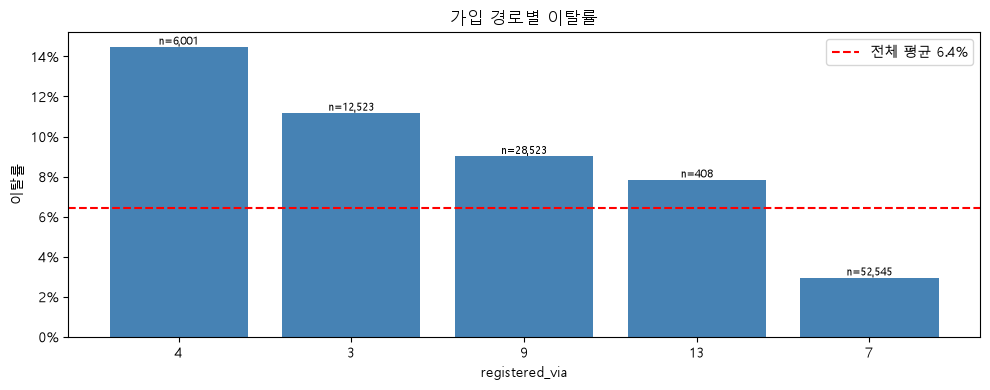

,churn_rate,count,lift
4,0.144809,6001,2.254893
3,0.111794,12523,1.740802
9,0.090173,28523,1.404124
13,0.078431,408,1.221292
7,0.029479,52545,0.459039


In [11]:
# 4-2. 가입 경로
plot_churn(df, "registered_via", title="가입 경로별 이탈률", sort_by_rate=True)

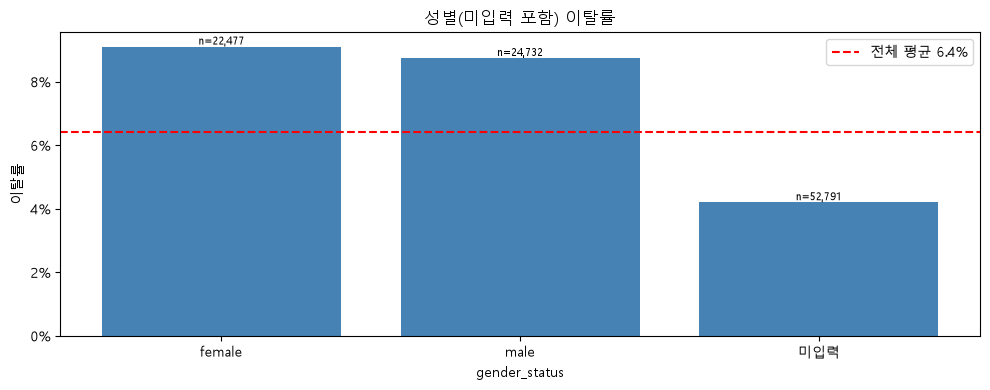

,churn_rate,count,lift
female,0.090982,22477,1.416722
male,0.087377,24732,1.360584
미입력,0.041977,52791,0.653641


In [12]:
# 4-3. 성별 (미입력 포함)
plot_churn(df, "gender_status", title="성별(미입력 포함) 이탈률")

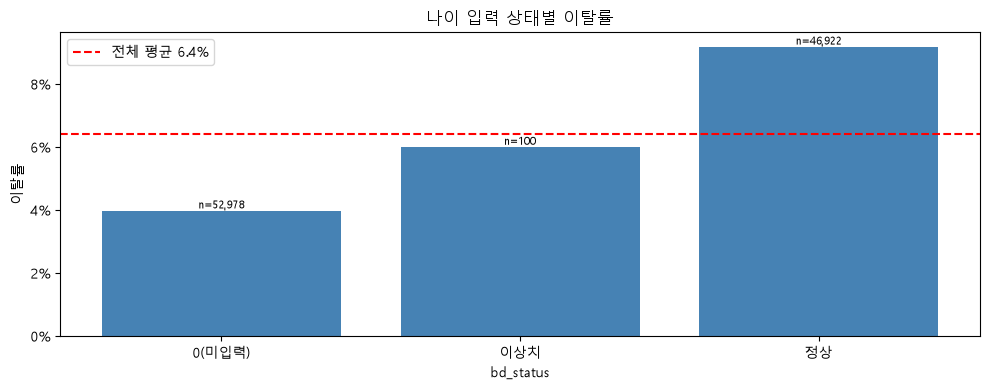

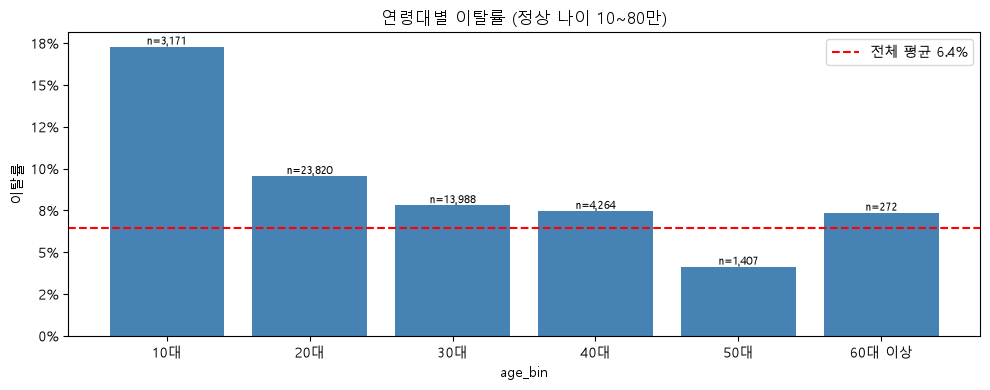

,churn_rate,count,lift
10대,0.172816,3171,2.691002
20대,0.095424,23820,1.485892
30대,0.077995,13988,1.214504
40대,0.074578,4264,1.161287
50대,0.041222,1407,0.641894
60대 이상,0.073529,272,1.144961


In [13]:
# 4-4. 나이: 먼저 상태별(0/정상/이상치), 그다음 정상 나이만 연령대별
plot_churn(df, "bd_status", title="나이 입력 상태별 이탈률")
plot_churn(df.dropna(subset=["age_bin"]), "age_bin", title="연령대별 이탈률 (정상 나이 10~80만)")  # dropna(subset=...): 해당 컬럼이 빈 행만 제외

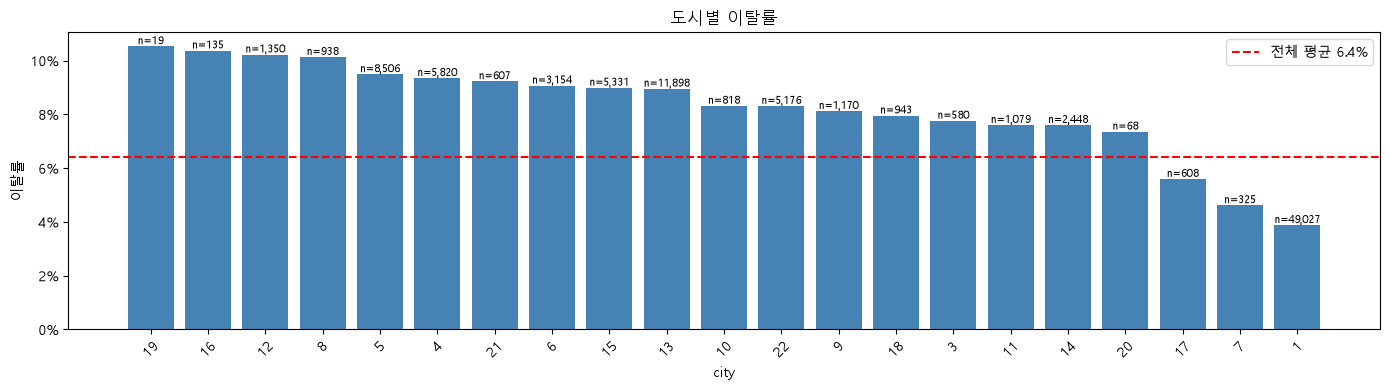

,churn_rate,count,lift
19,0.105263,19,1.639102
16,0.103704,135,1.614819
12,0.102222,1350,1.591751
8,0.101279,938,1.577068
5,0.094874,8506,1.477331
4,0.093471,5820,1.455478
21,0.092257,607,1.436577
6,0.090679,3154,1.411998
15,0.089852,5331,1.399125
13,0.089511,11898,1.393816


In [14]:
# 4-5. 도시: 그룹이 많으므로 이탈률 순 정렬
plot_churn(df, "city", title="도시별 이탈률", sort_by_rate=True, figsize=(14, 4))

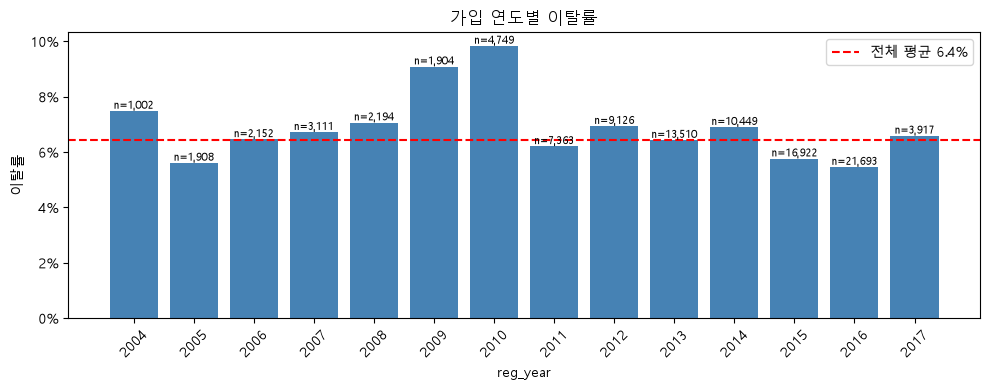

,churn_rate,count,lift
2004,0.074850,1002,1.165529
2005,0.056080,1908,0.873243
2006,0.064591,2152,1.005778
2007,0.067181,3111,1.046107
2008,0.070647,2194,1.100081
2009,0.090861,1904,1.414845
2010,0.098336,4749,1.531244
2011,0.062067,7363,0.966476
2012,0.069362,9126,1.080073
2013,0.064323,13510,1.001600


In [15]:
# 4-6. 가입 연도 (가입 기간과 같은 정보를 연 단위로 본 것 — 둘 중 발표용으로 하나 선택)
plot_churn(df, "reg_year", title="가입 연도별 이탈률")

## 5. 결측·이상값 자체의 의미
'비어 있다'는 사실이 이탈과 관련 있는지 봅니다.

In [16]:
# 각 항목을 0/1 플래그로. city==1은 결측은 아니지만, 미입력 시 기본값일 가능성을 가설로 두고 포함
df["flag_gender_missing"] = df["gender"].isna().astype(int)
df["flag_bd_zero"] = (df["bd"] == 0).astype(int)
df["flag_city_1"] = (df["city"] == 1).astype(int)

# 세 플래그가 서로 얼마나 겹치는지: 많이 겹치면 '프로필을 안 채운 사람'이라는 한 집단일 가능성
flags = ["flag_gender_missing", "flag_bd_zero", "flag_city_1"]
display(df[flags].corr().round(2))

# crosstab: 두 변수의 조합별 인원 수 표
display(pd.crosstab(df["flag_gender_missing"], df["flag_bd_zero"], margins=True))  # margins=True → 합계 행·열 추가

,flag_gender_missing,flag_bd_zero,flag_city_1
flag_gender_missing,1.00,0.95,0.86
flag_bd_zero,0.95,1.00,0.87
flag_city_1,0.86,0.87,1.00


flag_bd_zero,0,1,All
flag_gender_missing,,,
0,45802,1407,47209
1,1220,51571,52791
All,47022,52978,100000


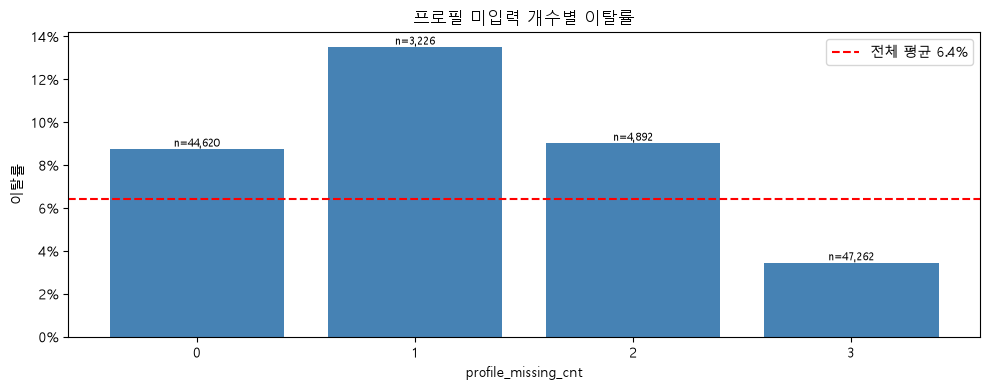

,churn_rate,count,lift
0,0.087606,44620,1.364162
1,0.135152,3226,2.104514
2,0.090352,4892,1.406907
3,0.034594,47262,0.538686


In [17]:
# 프로필 미입력 개수 0~3: 3이면 성별·나이·도시 모두 기본값/빈칸
df["profile_missing_cnt"] = df[flags].sum(axis=1)   # axis=1 → 행 방향(가로)으로 더함
plot_churn(df, "profile_missing_cnt", title="프로필 미입력 개수별 이탈률", order=[0, 1, 2, 3])

In [18]:
# 플래그 하나씩 따로 보기: 어느 항목이 이탈률 차이를 가장 크게 만드는지
pd.concat({f: churn_table(df, f) for f in flags})

churn_rate  count      lift
                    flag_gender_missing                             
flag_gender_missing 0                      0.089093  47209  1.387312
                    1                      0.041977  52791  0.653641
flag_bd_zero        0                      0.091744  47022  1.428594
                    1                      0.039790  52978  0.619590
flag_city_1         0                      0.088694  50973  1.381096
                    1                      0.038775  49027  0.603777

## 6. 변수 간 관계
4번에서 본 가입 경로의 차이가 '경로 자체' 때문인지, '가입 시기' 때문인지 구분합니다.

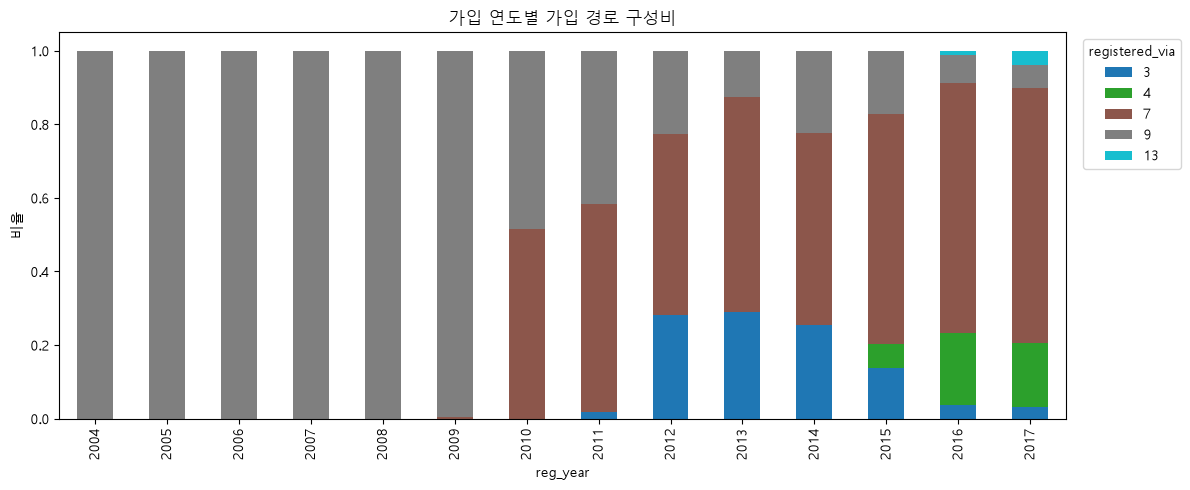

In [19]:
# 6-1. 가입 연도별로 어떤 경로가 많았는지
# normalize="index" → 각 행(연도)의 합이 1이 되도록 비율로 변환
via_by_year = pd.crosstab(df["reg_year"], df["registered_via"], normalize="index")
via_by_year.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
plt.title("가입 연도별 가입 경로 구성비")
plt.ylabel("비율")
plt.legend(title="registered_via", bbox_to_anchor=(1.01, 1))   # bbox_to_anchor: 범례를 그래프 밖 오른쪽에
plt.tight_layout()
plt.show()

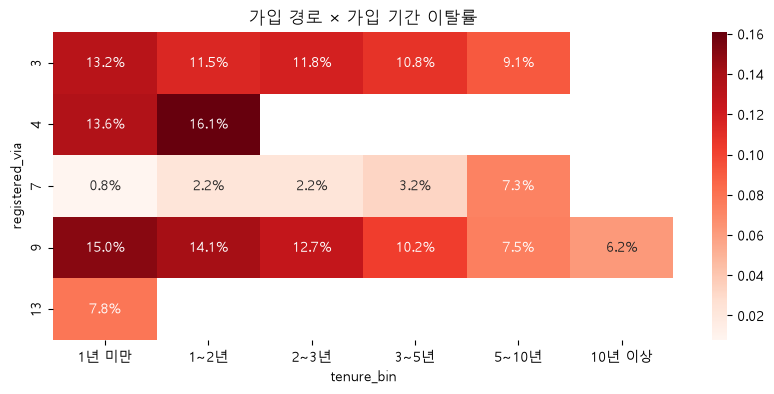

tenure_bin,1년 미만,1~2년,2~3년,3~5년,5~10년,10년 이상
registered_via,,,,,,
3,734.0,1838.0,2672.0,6742.0,537.0,NaN
4,3813.0,2188.0,NaN,NaN,NaN,NaN
7,12587.0,14729.0,4287.0,12313.0,8629.0,NaN
9,1457.0,2446.0,2700.0,3698.0,12389.0,5833.0
13,408.0,NaN,NaN,NaN,NaN,NaN


In [20]:
# 6-2. 같은 가입 기간 안에서도 경로별 이탈률 차이가 유지되는가
# pivot_table: index=행, columns=열, values=계산할 값, aggfunc=계산 방식
pivot_rate = df.pivot_table(index="registered_via", columns="tenure_bin",
                            values="is_churn", aggfunc="mean", observed=True)
pivot_cnt = df.pivot_table(index="registered_via", columns="tenure_bin",
                           values="is_churn", aggfunc="size", observed=True)

plt.figure(figsize=(10, 4))
# annot=True: 칸마다 값 표시 / fmt=".1%": 퍼센트 소수 1자리 / cmap: 색상표(진할수록 이탈률 높음)
sns.heatmap(pivot_rate, annot=True, fmt=".1%", cmap="Reds")
plt.title("가입 경로 × 가입 기간 이탈률")
plt.show()
pivot_cnt   # 칸별 인원 수: 인원이 적은 칸은 해석 주의
# 읽는 법: 같은 열(같은 가입 기간) 안에서도 경로별 색 차이가 크면 → 경로 자체의 영향

In [ ]:
# 6-3. 가입 경로 × 프로필 미입력 개수: 특정 경로가 프로필을 안 채우는 경로인지
pd.crosstab(df["registered_via"], df["profile_missing_cnt"], normalize="index").round(3)

## 7. 요약: 이탈 위험이 높은 고객 집단 Top N
관리자 서비스의 '이탈 원인 제시' 기능으로 이어지는 결론 부분입니다.

In [22]:
SEGMENT_COLS = ["registered_via", "tenure_bin", "gender_status"]   # 조합할 기준 컬럼
MIN_COUNT = 300   # 이 인원 미만인 조합은 제외: 너무 작은 집단의 우연한 고이탈률을 거르는 기준
TOP_N = 10

seg = churn_table(df, SEGMENT_COLS, min_count=MIN_COUNT)
top = seg.sort_values("churn_rate", ascending=False).head(TOP_N)
top["churn_rate"] = (top["churn_rate"] * 100).round(1).astype(str) + "%"
top["lift"] = top["lift"].round(2)
top

churn_rate  count  lift
registered_via tenure_bin gender_status                        
4              1~2년       male               17.6%    659  2.74
                          female             16.7%    580  2.60
9              1~2년       female             16.2%    554  2.53
                          male               16.0%    625  2.49
               1년 미만      male               15.4%    356  2.41
                          미입력                15.1%    757  2.34
4              1~2년       미입력                14.6%    949  2.28
9              2~3년       male               14.5%    770  2.26
               1년 미만      female             14.5%    344  2.26
4              1년 미만      미입력                14.4%   1912  2.24